In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install diffusers transformers accelerate torch

Starting Training...


100%|██████████| 782/782 [03:26<00:00,  3.79it/s, MSE=0.0258]


Epoch 5 finished. Saving visuals...


999it [00:29, 33.43it/s]


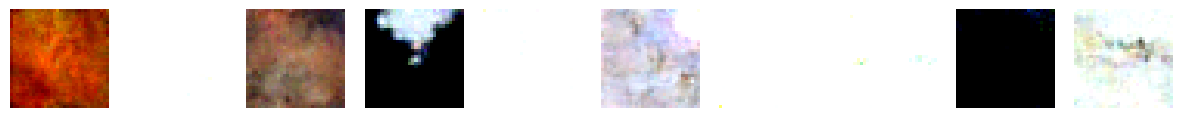

100%|██████████| 782/782 [03:30<00:00,  3.72it/s, MSE=0.0256]


Epoch 10 finished. Saving visuals...


999it [00:29, 33.47it/s]


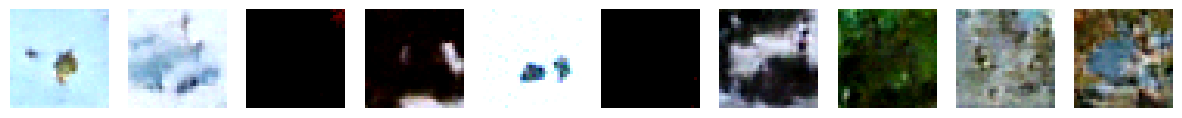

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. HYPERPARAMETERS
# ==========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
image_size = 32
channels = 3
batch_size = 64
num_classes = 10
lr = 1e-4
epochs = 10 
timesteps = 1000
beta_start = 1e-4
beta_end = 0.02

# ==========================================
# 2. DIFFUSION SCHEDULER (FROM SCRATCH)
# ==========================================
class DiffusionScheduler:
    def __init__(self, timesteps, beta_start, beta_end, device):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

    def add_noise(self, x_start, t):
        """Forward process: add Gaussian noise to the image"""
        noise = torch.randn_like(x_start)
        # Reshape for broadcasting
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise, noise

# ==========================================
# 3. CONDITIONAL UNET ARCHITECTURE
# ==========================================
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        size = x.shape[-1]
        # Reshape for attention: (N, C, H, W) -> (N, H*W, C)
        x = x.view(-1, x.shape[1], size * size).swapaxes(1, 2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln, x_ln, x_ln)
        x = attention_value + x
        x = self.ff_self(x) + x
        # Swap back: (N, H*W, C) -> (N, C, H, W)
        return x.swapaxes(2, 1).view(-1, x.shape[2], size, size)

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None, residual=False):
        super().__init__()
        self.residual = residual
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)

class UnetConditional(nn.Module):
    def __init__(self, c_in=3, c_out=3, time_dim=256, num_classes=10):
        super().__init__()
        self.time_dim = time_dim
        self.inc = DoubleConv(c_in, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.attn1 = SelfAttention(128)
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.attn2 = SelfAttention(256)
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 256))
        self.attn3 = SelfAttention(256)

        self.bot1 = DoubleConv(256, 512)
        self.bot2 = DoubleConv(512, 512)
        self.bot3 = DoubleConv(512, 256)

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.sa1 = DoubleConv(512, 256)
        self.attn4 = SelfAttention(256)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.sa2 = DoubleConv(384, 128)
        self.attn5 = SelfAttention(128)
        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.sa3 = DoubleConv(192, 64)
        self.attn6 = SelfAttention(64)
        self.outc = nn.Conv2d(64, c_out, kernel_size=1)

        self.label_emb = nn.Embedding(num_classes, time_dim)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, channels, 2, device=device).float() / channels))
        pos_enc_a = torch.sin(t.repeat(1, channels // 2) * inv_freq)
        pos_enc_b = torch.cos(t.repeat(1, channels // 2) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
        return pos_enc

    def forward(self, x, t, y):
        # Time Embedding
        t = t.unsqueeze(-1).type(torch.float)
        t = self.pos_encoding(t, self.time_dim)

        # Class Embedding (Conditioning)
        if y is not None:
            t += self.label_emb(y)

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x2 = self.attn1(x2)
        x3 = self.down2(x2)
        x3 = self.attn2(x3)
        x4 = self.down3(x3)
        x4 = self.attn3(x4)

        x4 = self.bot1(x4)
        x4 = self.bot2(x4)
        x4 = self.bot3(x4)

        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.sa1(x)
        x = self.attn4(x)
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.sa2(x)
        x = self.attn5(x)
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.sa3(x)
        x = self.attn6(x)
        output = self.outc(x)
        return output

# ==========================================
# 4. DATA LOADING
# ==========================================
def get_data():
    tf = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf)
    return DataLoader(trainset, batch_size=batch_size, shuffle=True)

# ==========================================
# 5. CORE LOGIC: SAMPLING (DDIM)
# ==========================================
@torch.no_grad()
def sample_ddim(model, scheduler, n, labels, cfg_scale=3):
    model.eval()
    x = torch.randn((n, 3, image_size, image_size)).to(device)
    
    # Simple DDIM logic: Skip steps if needed, but here we run full steps for quality
    # Classifier-Free Guidance (CFG) included
    for i in tqdm(reversed(range(1, scheduler.timesteps)), position=0):
        t = (torch.ones(n) * i).long().to(device)
        
        # Predict noise with condition
        predicted_noise = model(x, t, labels)
        
        # CFG logic: Interpolate between conditional and unconditional prediction
        if cfg_scale > 0:
            uncond_predicted_noise = model(x, t, None)
            predicted_noise = torch.lerp(uncond_predicted_noise, predicted_noise, cfg_scale)
        
        alpha = scheduler.alphas[i]
        alpha_hat = scheduler.alphas_cumprod[i]
        beta = scheduler.betas[i]
        
        if i > 1:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)
            
        x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
    
    model.train()
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# ==========================================
# 6. TRAINING LOOP
# ==========================================
def train():
    dataloader = get_data()
    model = UnetConditional(num_classes=num_classes).to(device)
    scheduler = DiffusionScheduler(timesteps, beta_start, beta_end, device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    
    print("Starting Training...")
    for epoch in range(epochs):
        pbar = tqdm(dataloader)
        for i, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)
            t = torch.randint(low=1, high=timesteps, size=(images.shape[0],)).to(device)
            
            # Classifier-Free Guidance: 10% of labels are randomly dropped during training
            if np.random.random() < 0.1:
                labels = None
                
            x_noisy, noise = scheduler.add_noise(images, t)
            predicted_noise = model(x_noisy, t, labels)
            loss = mse(noise, predicted_noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            pbar.set_postfix(MSE=loss.item())

        # Save visuals every few epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1} finished. Saving visuals...")
            sample_labels = torch.arange(10).to(device)
            sampled_images = sample_ddim(model, scheduler, 10, sample_labels)
            
            # Simple grid plot
            plt.figure(figsize=(15, 3))
            for idx in range(10):
                plt.subplot(1, 10, idx+1)
                plt.imshow(sampled_images[idx].permute(1, 2, 0).cpu().numpy())
                plt.axis('off')
            plt.show()

if __name__ == "__main__":
    train()
